# Introduction to Statistics

#### Load the `jobs_no2015.csv` data. Call it `jobs`

In [2]:
# YOUR CODE HERE
import pandas as pd 
jobs=pd.read_csv("jobs_no2015.csv")
jobs
raise NotImplementedError()

NotImplementedError: 

#### Lets compare both male and female wages. Select the columns `year`, `minor_category` ,`total_earnings_male`, `total_earnings_female` and call the new data `jobs_earnings`

In [ ]:
# YOUR CODE HERE
import pandas as pd
jobs_earnings=pd.DataFrame(jobs,columns=["year", "minor_category" ,"total_earnings_male", "total_earnings_female"])
jobs_earnings
raise NotImplementedError()

#### Filter out 2014 from the dataset called `job_earnings` calling the filteres data `jobs_2014`

In [18]:
# YOUR CODE HERE
jobs_2014=jobs[jobs["year"]==2014]
jobs_2014
#raise NotImplementedError()

,year,occupation,major_category,minor_category,total_workers,workers_male,workers_female,percent_female,total_earnings,total_earnings_male,total_earnings_female,wage_percent_of_male
522,2014,Chief executives,"Management, Business, and Financial",Management,1013853,774838,239015,23.6,122136,130830.0,101174.0,77.332416
523,2014,General and operations managers,"Management, Business, and Financial",Management,761445,545655,215790,28.3,67100,74888.0,53539.0,71.492095
524,2014,Legislators,"Management, Business, and Financial",Management,14365,8413,5952,41.4,71632,76794.0,70059.0,91.229784
525,2014,Advertising and promotions managers,"Management, Business, and Financial",Management,44209,20591,23618,53.4,61097,75638.0,52378.0,69.248261
526,2014,Marketing and sales managers,"Management, Business, and Financial",Management,760335,434308,326027,42.9,80973,97067.0,65229.0,67.199975
...,...,...,...,...,...,...,...,...,...,...,...,...
1039,2014,Pumping station operators,"Production, Transportation, and Material Moving",Material Moving,24642,23111,1531,6.2,60028,60028.0,60208.0,NaN
1040,2014,Refuse and recyclable material collectors,"Production, Transportation, and Material Moving",Material Moving,66445,61465,4980,7.5,30571,30512.0,32203.0,NaN
1041,2014,Mine shuttle car operators,"Production, Transportation, and Material Moving",Material Moving,1331,1277,54,4.1,65463,51595.0,NaN,NaN
1042,2014,"Tank car, truck, and ship loaders","Production, Transportation, and Material Moving",Material Moving,3994,3498,496,12.4,32318,33566.0,19329.0,NaN


#### Calculate the mean earnings for females and call it `mean_female_earning`

In [ ]:
# YOUR CODE HERE
import numpy as np
mean_female_earning=jobs_2014["total_earnings_female"].mean()
mean_female_earning                          
raise NotImplementedError()

#### Calculate the mean earnings for males and call it `mean_male_earning`

In [ ]:
# YOUR CODE HERE
mean_male_earning=jobs_2014["total_earnings_male"].mean()
mean_male_earning    
raise NotImplementedError()

### Calculate the median income of females and males in the work force. Store it as `median_male_earning` and `median_female_earning`

In [ ]:
# YOUR CODE HERE
median_male_earning=jobs_2014["total_earnings_male"].median()
median_male_earning  
raise NotImplementedError()

In [ ]:
# YOUR CODE HERE
median_female_earning=jobs_2014["total_earnings_female"].median()
median_female_earning  
raise NotImplementedError()

### Calculate the standard deviation income of females and males in the work force. Store it as `std_male_earning` and `std_female_earning`

In [ ]:

# YOUR CODE HERE
std_male_earning=jobs_2014["total_earnings_male"].std()
std_male_earning
raise NotImplementedError()


In [ ]:

# YOUR CODE HERE
std_female_earning=jobs_2014["total_earnings_female"].std()
std_female_earning
raise NotImplementedError()


### Reshape the dataset and analyse income by gender and major category.

Tasks:

- Reshape the dataset into long format using the income columns:

   * men

   * women

The reshaped data frame should have the following columns:

   * `major_category`

   * `gender`

   * `income`

Group the data by:

   * `major_category`

   * `gender`

### Compute the `mean` income for each group.

### Create a bar plot of mean income facet by gender

Store your final grouped data as:

`mean_income_category_gender`
### Interpret the plot

In [ ]:
import  seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# YOUR CODE HERE

jobs_income = jobs_2014[["minor_category","total_earnings_male","total_earnings_female"]]

job_income=jobs_income.rename(columns={"total_earnings_male":"Men",
                                       "total_earnings_female": "Women",
                                        "minor_category":"major_category"})
jobs_long = job_income.melt(id_vars=["major_category"],
                       value_vars=["Men","Women"],
                       var_name="gender",value_name="income")
jobs_long

#raise NotImplementedError()

,major_category,gender,income
0,Management,Men,130830.0
1,Management,Men,74888.0
2,Management,Men,76794.0
3,Management,Men,75638.0
4,Management,Men,97067.0
...,...,...,...
1039,Material Moving,Women,60208.0
1040,Material Moving,Women,32203.0
1041,Material Moving,Women,NaN
1042,Material Moving,Women,19329.0


In [ ]:
#mean_major_category=jobs_long.groupby(["major_category"],as_index=False)["income"].mean()
#mean_major_category

In [ ]:
#mean_gender_category=jobs_long.groupby(["gender"],as_index=False)["income"].mean()
#mean_gender_category


In [20]:
mean_income =jobs_long.groupby(["major_category","gender"])["income"].mean().reset_index()
mean_income
#raise NotImplementedError()

,major_category,gender,income
0,Architecture and Engineering,Men,83866.523810
1,Architecture and Engineering,Women,74746.904762
2,"Arts, Design, Entertainment, Sports, and Media",Men,52535.166667
3,"Arts, Design, Entertainment, Sports, and Media",Women,44986.888889
4,Building and Grounds Cleaning and Maintenance,Men,32756.833333
5,Building and Grounds Cleaning and Maintenance,Women,26519.333333
6,Business and Financial Operations,Men,67598.107143
7,Business and Financial Operations,Women,53349.214286
8,Community and Social Service,Men,43564.375000
9,Community and Social Service,Women,40235.750000


In [30]:
mean_income["is_max"] = mean_income.groupby("gender")["income"].transform(lambda x: x==x.max())

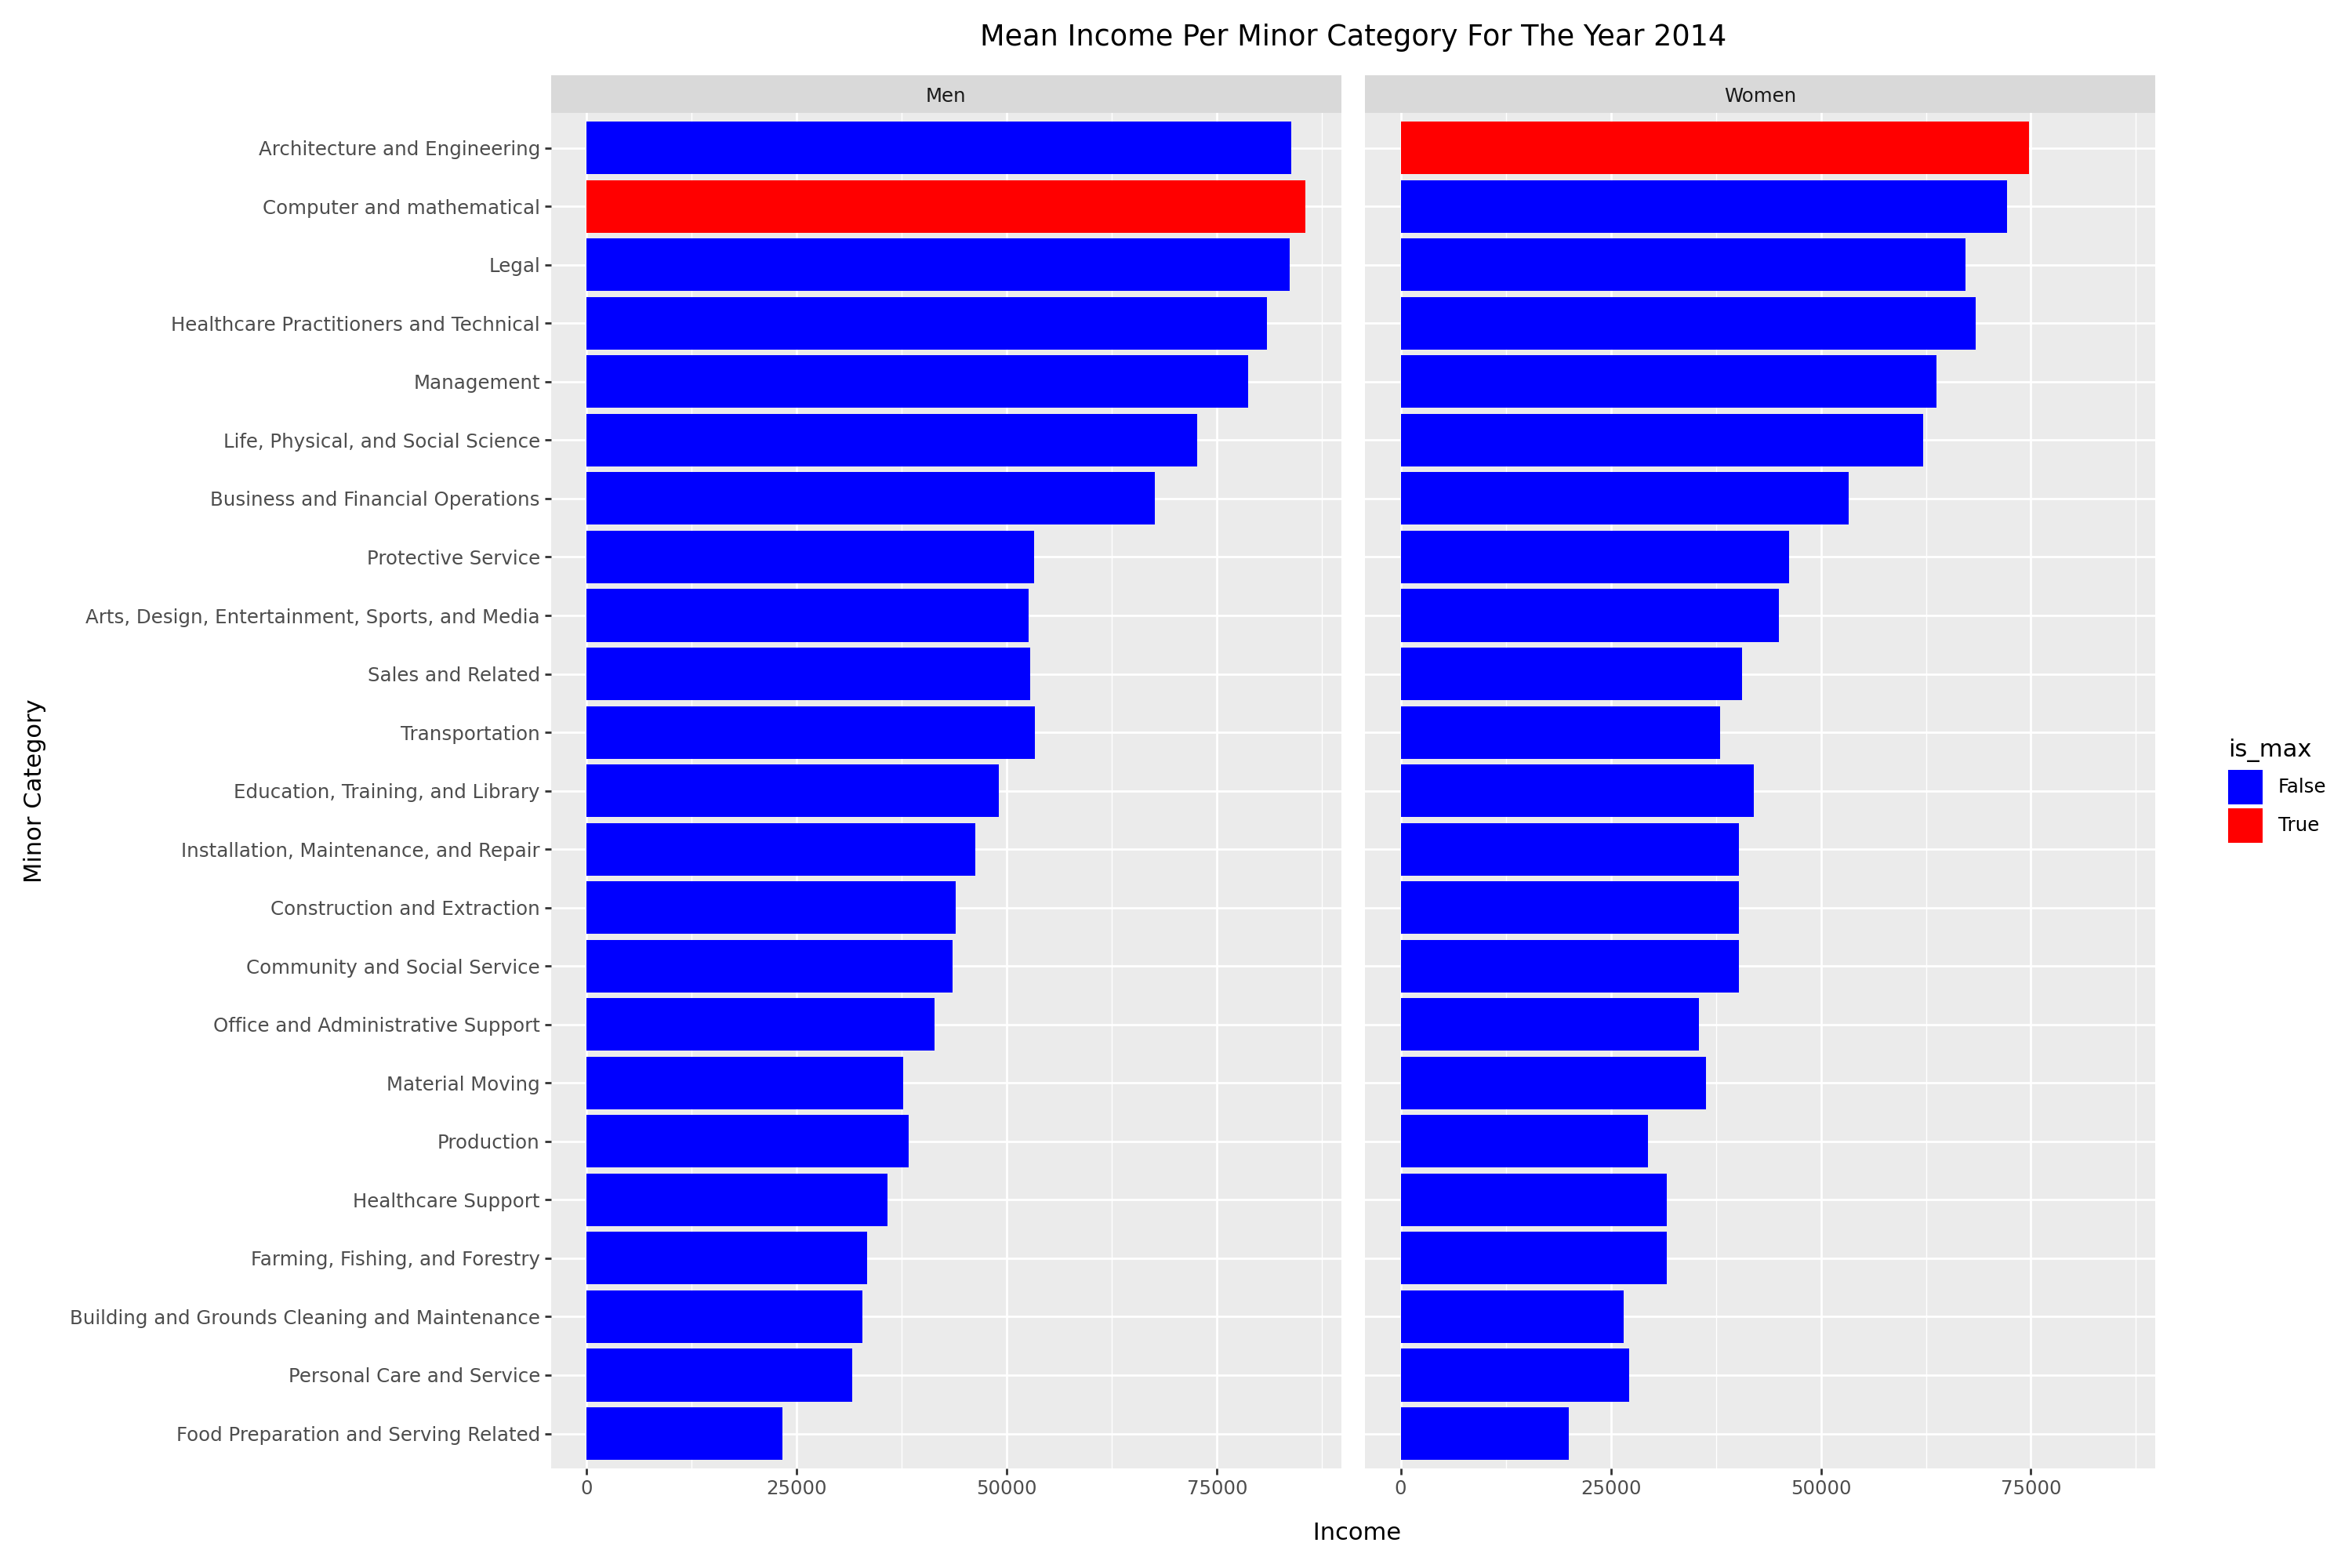

In [31]:
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
(
ggplot(mean_income,
           aes(x="reorder(major_category,income)",y="income",fill="is_max"))
+ geom_bar(stat="identity")
+ facet_wrap("~gender")
+ coord_flip()
+ labs(
 title="Mean Income Per Minor Category For The Year 2014",
    x="Minor Category",
    y=" Income")
+ scale_fill_manual(values={True:"red",False: "blue"})
+ theme(figure_size=(15,10))
)
#raiseNotImplementedError()